In [1]:
from ase.build import bulk

from atomdefectkit.basic_properties import BasicProperties
from atomdefectkit.screw import BCCScrewDislocation
from atomdefectkit.neb import BCCScrewDislocPeierlsBarrier

import numpy as np

from pyace import PyACECalculator

/Users/leizhang/Nextcloud/5_Coding/G_github/ASDbcc/.venv/lib/python3.11/site-packages/pyace/multispecies_basisextension.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Lattice constant difference is 0.0024895522264332115
Check the approach for getting lattice constant!


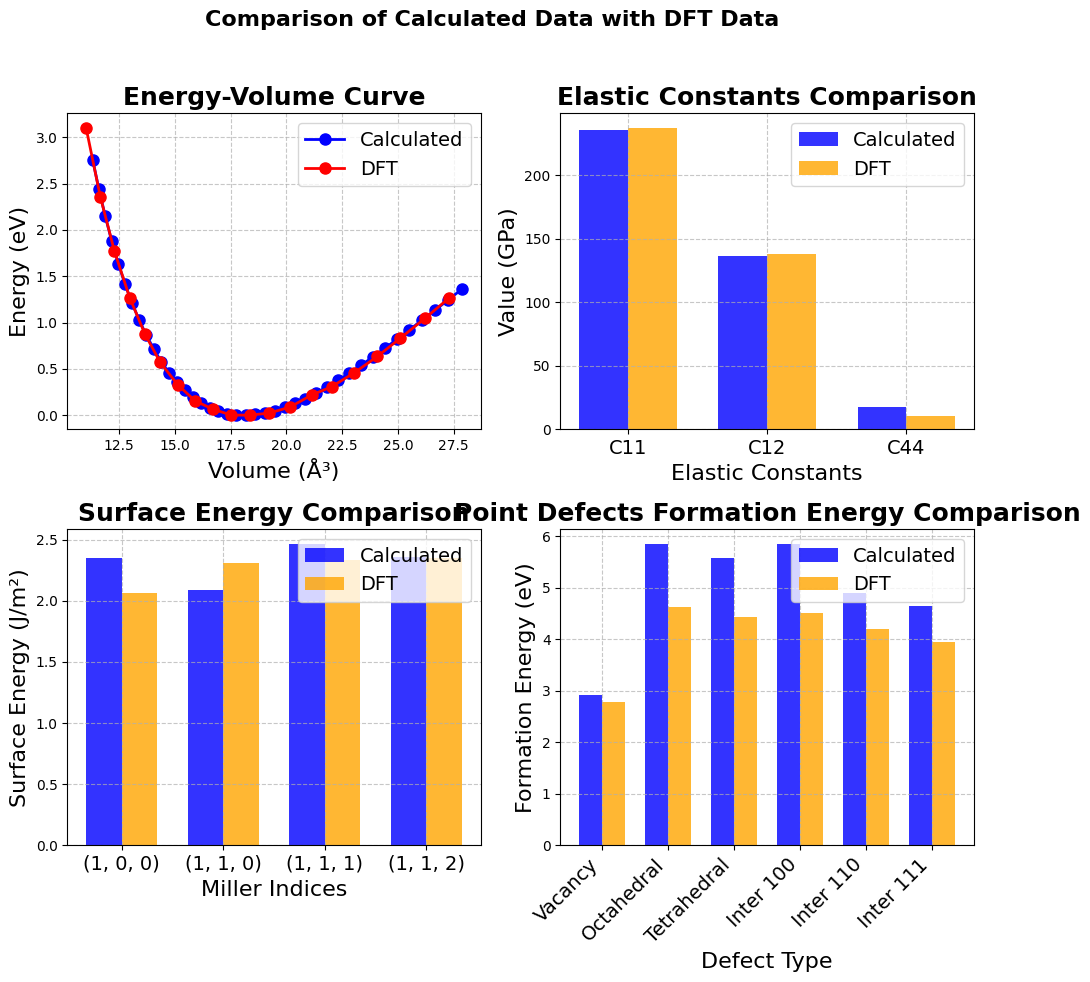

In [2]:
# Define the benchmark material and output location.
elem = 'Nb'
crystal_structure = 'bcc'
initial_a0 = 3.3  # Initial lattice-parameter guess in Angstrom.
working_dir = 'Test_Nb'

calc = PyACECalculator('/Users/leizhang/Nextcloud/1_Science_Postdoc_Projects/0_0_RUG_Screw_BCC/9_1_data_git/ACE2025_potential/Nb/output_potential.yaml')

# Initialize the basic-property workflow with a direct ACE calculator.
workflow = BasicProperties(calculator=calc, working_dir=working_dir)
calc = workflow.get_calculator()

# Build the conventional cubic BCC unit cell.
atoms = bulk(elem, crystal_structure, a=initial_a0, cubic=True)

# Estimate the equilibrium lattice parameter from both relaxation and EOS fitting.
a0_relax = workflow.calculate_equilibrium_a0_relax(atoms.copy(), fmax=0.001)
volumes, energies, a0_fit = workflow.calculate_equilibrium_a0_birch_murnaghan(atoms.copy(), vol_range=np.linspace(0.95, 1.05, 40))

# Sanity-check that the two lattice-parameter estimates agree.
if abs(a0_relax - a0_fit) > 1e-4:
    print('Lattice constant difference is', abs(a0_relax - a0_fit))
    print('Check the approach for getting lattice constant!')

# Update the bulk cell before computing defect and surface properties.
atoms.set_cell([a0_fit] * 3, scale_atoms=True)
Cij = workflow.calculate_elastic_constants(atoms.copy(), verbose=False)
vacancy_formation_energy = workflow.calculate_vacancy_formation_energy(atoms)

# Evaluate representative interstitial and vacancy formation energies.
octahedral_formation_energy = workflow.calculate_interstitial_formation_energy(atoms.copy(), 
                                                                               elem, 
                                                                               a0_fit * np.array([0.5, 0.5, 0]))
tetrahedral_formation_energy = workflow.calculate_interstitial_formation_energy(atoms.copy(), 
                                                                                elem, 
                                                                                a0_fit * np.array([0.25, 0.5, 0]))
inter_100_formation_energy = workflow.calculate_interstitial_formation_energy(atoms.copy(), 
                                                                              elem, 
                                                                              a0_fit * np.array([0.5, 0.5, 0]))
inter_110_formation_energy = workflow.calculate_interstitial_formation_energy(atoms.copy(), 
                                                                              elem, 
                                                                              a0_fit * np.array([0.1, 0.1, 0.5]))
inter_111_formation_energy = workflow.calculate_interstitial_formation_energy(atoms.copy(), 
                                                                              elem, 
                                                                              a0_fit * np.array([[0.33, 0.33, 0.33],[0.7, 0.7, 0.7]]), 
                                                                              dumbbell=True)

# Calculate surface energies for a small benchmark set of facets.
surface_energy = np.zeros(4)
miller_indices_list = [(1, 0, 0), (1, 1, 0), (1, 1, 1), (1, 1, 2)]
for i, miller_indices in enumerate(miller_indices_list):
    surface_energy[i] = workflow.calculate_surface_energy(atoms, miller_indices, vacuum=20, n_layers=8)

workflow.save_properties(
    volumes=volumes,
    energies=energies,
    Cij=Cij,
    surface_energy=surface_energy,
    vacancy_formation_energy=vacancy_formation_energy,
    octahedral_formation_energy=octahedral_formation_energy,
    tetrahedral_formation_energy=tetrahedral_formation_energy,
    inter_100_formation_energy=inter_100_formation_energy,
    inter_110_formation_energy=inter_110_formation_energy,
    inter_111_formation_energy=inter_111_formation_energy,
    save_name=f'{elem}_basicProp.json'
)

# Plot the calculated properties against the stored DFT reference data.
workflow.plot_comparison(workflow.path(f"{elem}_basicProp.json"), f'../data/basic_properties/dft_{elem}.json')

# Calculate stacking fault energy curve

/Users/leizhang/Nextcloud/5_Coding/G_github/ASDbcc/src/atomdefectkit/basic_properties.py:279: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [-0.50000,  0.50000,  0.50000]
  [ 0.50000, -0.50000,  0.50000]
  [ 0.50000,  0.50000, -0.50000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = Phonopy(


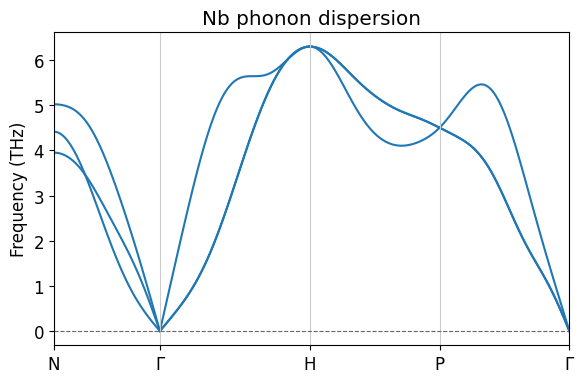

In [3]:
special_points = {
    "G": (0.0, 0.0, 0.0),
    "H": (0.5, -0.5, 0.5),
    "N": (0.0, 0.0, 0.5),
    "P": (0.25, 0.25, 0.25),
}

labels_path = [["N", "G", "H", "P", "G"]]

fig_path = workflow.calculate_phonon_dispersion(
    structure=atoms,
    special_points=special_points,
    labels_path=labels_path,
    supercell_matrix=np.diag([4, 4, 4]),
)